# Mushroom Classification ML
Source: https://www.kaggle.com/datasets/zedsden/mushroom-classification-dataset

In [1]:
import pandas as pd
import numpy as np
import re
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from wakepy import keep
with keep.running(on_fail='warn'):
    print("Task is running...")

Task is running...


# Load the dataset cleaned_mushroom_dataset1.csv

#### Further clean the dataset
- more feature engineering -> data cleaning and feature standardization before modeling.

1. Exploration of the dataset1 again after de-duplication
2. 

In [2]:
# 1. Load the cleaned dataset
df = pd.read_csv('cleaned_mushroom_dataset1.csv')

In [3]:
df.shape

(94631, 12)

In [4]:
df.head(10)

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,abb9d4a0aae5c4d4
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a581b66e5c2d6b32
2,Classes/conditionally_edible/horn_of_plenty/14...,3,14,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,d8f40799f31ea870
3,Classes/conditionally_edible/horn_of_plenty/12...,3,12,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a8a8e950d4af3f58
4,Classes/conditionally_edible/horn_of_plenty/13...,3,13,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,8e86638cdcad5bd0
5,Classes/conditionally_edible/horn_of_plenty/11...,3,11,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a0b2cf41e0afde0e
6,Classes/conditionally_edible/horn_of_plenty/10...,3,10,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,cde6d0c836cb07c6
7,Classes/conditionally_edible/horn_of_plenty/4.png,3,4,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,88bd470f603c3de3
8,Classes/conditionally_edible/horn_of_plenty/5.png,3,5,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a693018e7926aeee
9,Classes/conditionally_edible/horn_of_plenty/7.png,3,7,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,bf8991d1c7d2a4c8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94631 entries, 0 to 94630
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   file_path     94631 non-null  object 
 1   depth         94631 non-null  int64  
 2   file_name     94631 non-null  object 
 3   file_ext      94631 non-null  object 
 4   width         94631 non-null  int64  
 5   height        94631 non-null  int64  
 6   aspect_ratio  94631 non-null  float64
 7   megapixels    94631 non-null  float64
 8   orientation   94631 non-null  object 
 9   class         94631 non-null  object 
 10  species       94631 non-null  object 
 11  phash         94631 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 8.7+ MB


In [6]:
df.describe()

,depth,width,height,aspect_ratio,megapixels
count,94631.000000,94631.000000,94631.000000,94631.000000,94631.000000
mean,3.058015,442.145650,422.347370,1.098890,0.192946
std,0.233773,141.794657,114.074508,0.355833,0.100622
min,3.000000,90.000000,90.000000,0.252000,0.008100
25%,3.000000,375.000000,368.000000,0.750000,0.166500
50%,3.000000,500.000000,500.000000,1.070664,0.187500
75%,3.000000,500.000000,500.000000,1.333333,0.187500
max,4.000000,1280.000000,1024.000000,4.385965,1.303552


In [7]:
len(df)

94631

In [8]:
df['class'].nunique()

4

In [9]:
df['species'].nunique()

570

In [10]:
df['file_ext'].nunique()

4

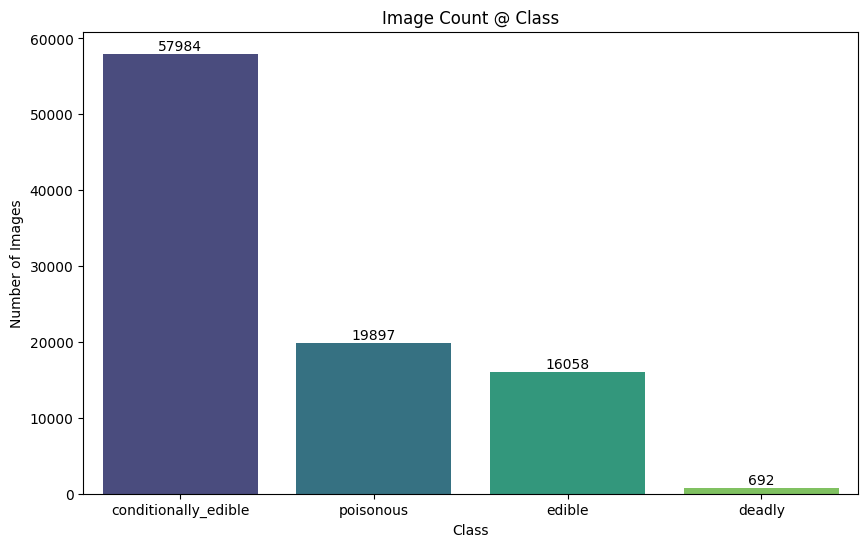

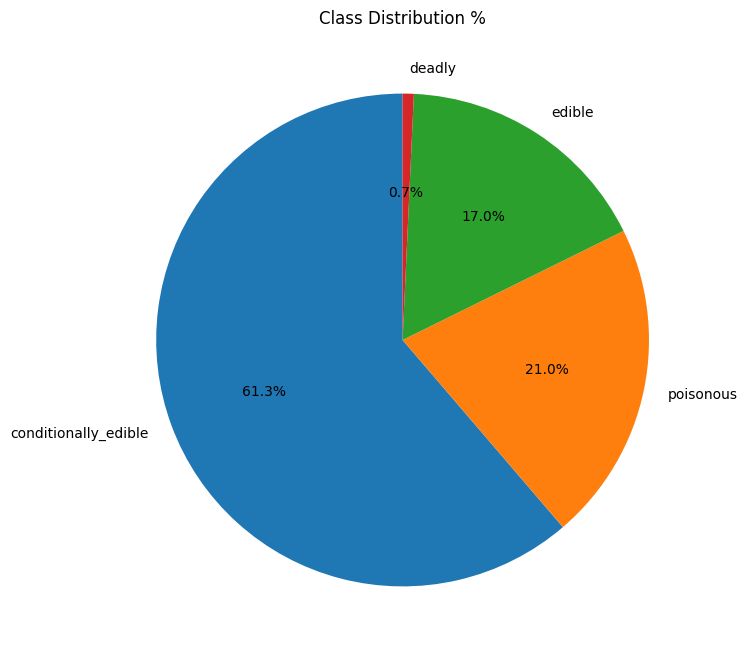

In [11]:
class_counts = df['class'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Image Count @ Class')
plt.ylabel('Number of Images')
plt.xlabel('Class')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 500, str(v), ha='center')
plt.show()

# Pie chart for proportions
plt.figure(figsize=(8, 8))
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution %')
plt.show()

In [12]:
species_per_class = df.groupby('class')['species'].nunique()
print("Unique Species per Class:\n", species_per_class)

Unique Species per Class:
 class
conditionally_edible    175
deadly                   36
edible                  154
poisonous               213
Name: species, dtype: int64


In [13]:
images_per_class_top = df.groupby(['class', 'species']).size().groupby('class').nlargest(5)
print("\nTop 5 Species per Class by Image Count:\n", images_per_class_top)


Top 5 Species per Class by Image Count:
 class                 class                 species              
conditionally_edible  conditionally_edible  Fomes fomentarius        5246
                                            Fomitopsis pinicola      5090
                                            Parmelia sulcata         2643
                                            Laetiporus sulphureus    2296
                                            Hypogymnia physodes      2159
deadly                deadly                Amanita_arocheae           38
                                            Galerina_marginata         37
                                            Paxillus_involutus         34
                                            Lepiota_subincarnata       32
                                            Cortinarius_splendens      31
edible                edible                Cerioporus squamosus     1518
                                            Coprinus comatus         1303
    

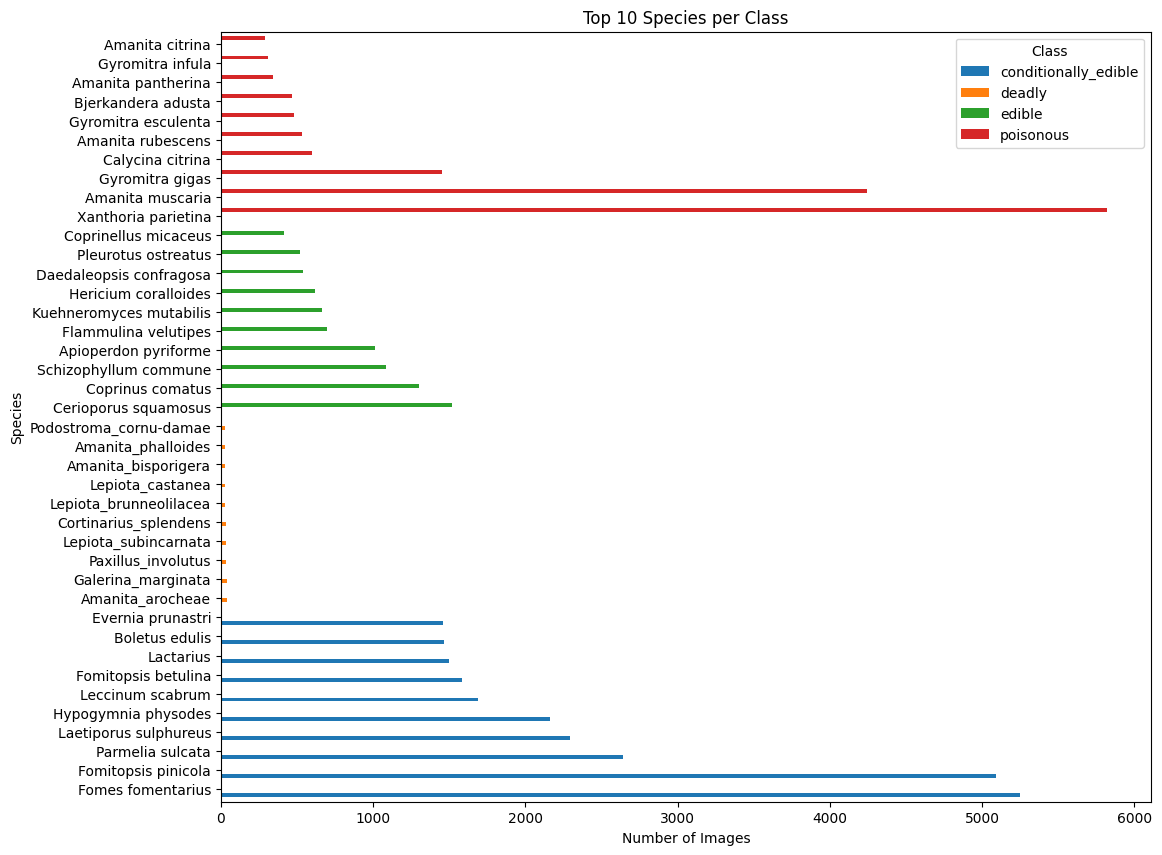

In [14]:
top_per_class = df.groupby('class')['species'].value_counts().groupby('class').head(10)

# Unstack for plotting
top_per_class.unstack(level=0).plot(kind='barh', figsize=(12, 10), width=0.8)
plt.title('Top 10 Species per Class')
plt.xlabel('Number of Images')
plt.ylabel('Species')
plt.legend(title='Class')
plt.show()

In [15]:
print("Species with ≤ 10 images:")
print(df['species'].value_counts()[lambda x: x <= 10].sort_values())

print("\nSpecies with ≥ 1000 images per class:")
print(df.groupby('class')['species'].value_counts().loc[lambda x: x >= 1000])

Species with ≤ 10 images:
species
truffles                    4
devils_bolete               8
deadly_webcap               8
orange_birch_bolete         8
cinnamon_bracket            9
golden_bootleg             10
hoof_fungus                10
Amanita_virosa             10
oak_polypore               10
cedarwood_waxcap           10
leccinum_albostipitatum    10
smoky_bracket              10
rooting_shank              10
Boletus_pulcherrimus       10
Name: count, dtype: int64

Species with ≥ 1000 images per class:
class                 species              
conditionally_edible  Fomes fomentarius        5246
                      Fomitopsis pinicola      5090
                      Parmelia sulcata         2643
                      Laetiporus sulphureus    2296
                      Hypogymnia physodes      2159
                      Leccinum scabrum         1691
                      Fomitopsis betulina      1585
                      Lactarius                1498
                     

In [16]:
df.groupby('class')[['width', 'height', 'megapixels']].agg(['mean','min','max','count'])

width                        height             \
                            mean  min   max  count        mean  min   max   
class                                                                       
conditionally_edible  475.742463  100  1280  57984  446.630122  100  1024   
deadly                203.919075  100   387    692  175.578035  100   345   
edible                404.116079   90   512  16058  395.755200   90   512   
poisonous             383.214857   94   512  19897  381.626175   90   512   

                            megapixels                             
                      count       mean       min       max  count  
class                                                              
conditionally_edible  57984   0.215825  0.010000  1.303552  57984  
deadly                  692   0.038272  0.010000  0.050625    692  
edible                16058   0.164882  0.008100  0.262144  16058  
poisonous             19897   0.154298  0.008742  0.262144  19897

### Check the number of files were skipped (i.e. could not be successfully read or processed)

1. Check missing values.
2. Check duplicate rows.
3. Check duplicate pHash values - potential duplicate images.
4. Check inconsistent species naming - underscores vs spaces, etc.
5. Check zero or negative dimensions.
6. Check class balance statistics.
7. Check species distribution per class.
8. Check any naming inconsistencies

In [29]:
# check the dataframe for various inconsistencies

print("- MISSING VALUES CHECK")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n- DUPLICATE ROWS CHECK")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print("\n- DUPLICATE pHASH CHECK")
duplicate_phash = df['phash'].duplicated().sum()
print(f"Number of duplicate pHash values: {duplicate_phash}")

print("\n- SPECIES NAMING PATTERNS CHECK")
species_with_underscores = df[df['species'].str.contains('_', na=False)]['species'].nunique()
species_with_spaces = df[df['species'].str.contains(' ', na=False)]['species'].nunique()
print(f"Species with underscores: {species_with_underscores}")
print(f"Species with spaces: {species_with_spaces}")

print("\n- IMAGE DIMENSION CHECKS")
invalid_width = df[df['width'] <= 0].shape[0]
invalid_height = df[df['height'] <= 0].shape[0]
print(f"Rows with invalid width (≤0): {invalid_width}")
print(f"Rows with invalid height (≤0): {invalid_height}")

print("\n- CLASS BALANCE SUMMARY")
class_stats = df['class'].value_counts()
print(f"Most frequent class: {class_stats.index[0]} ({class_stats.values[0]} images)")
print(f"Least frequent class: {class_stats.index[-1]} ({class_stats.values[-1]} images)")

print("\n- SPECIES DISTRIBUTION PER CLASS")
species_per_class = df.groupby('class')['species'].nunique()
print(species_per_class)

- MISSING VALUES CHECK
Series([], dtype: int64)

- DUPLICATE ROWS CHECK
Number of duplicate rows: 0

- DUPLICATE pHASH CHECK
Number of duplicate pHash values: 0

- SPECIES NAMING PATTERNS CHECK
Species with underscores: 0
Species with spaces: 519

- IMAGE DIMENSION CHECKS
Rows with invalid width (≤0): 0
Rows with invalid height (≤0): 0

- CLASS BALANCE SUMMARY
Most frequent class: conditionally_edible (58196 images)
Least frequent class: deadly (648 images)

- SPECIES DISTRIBUTION PER CLASS
class
conditionally_edible    169
deadly                   28
edible                  143
poisonous               202
Name: species, dtype: int64


In [18]:
# regex patterns 
leading_trailing = r'^\s|\s$'
multiple_spaces = r'\s{2,}'
special_chars = r'[^a-zA-Z0-9\s-]'

# use the variables in f-strings
print(f"- Case variations: {df['species'].str.lower().duplicated().any()}")
print(f"- Has leading/trailing spaces: {df['species'].str.contains(leading_trailing, regex=True).any()}")
print(f"- Has multiple spaces: {df['species'].str.contains(multiple_spaces, regex=True).any()}")
print(f"- Has underscores: {df['species'].str.contains('_').any()}")
print(f"- Has special characters: {df['species'].str.contains(special_chars, regex=True).any()}")
print(f"- Species in multiple classes: {(df.groupby('species')['class'].nunique() > 1).any()}")

- Case variations: True
- Has leading/trailing spaces: False
- Has multiple spaces: False
- Has underscores: True
- Has special characters: True
- Species in multiple classes: True


In [19]:
print(f"Unique species BEFORE: {df['species'].nunique()}")

# fix species names - case, underscores, spaces, special chars
df['species'] = df['species'].str.strip().str.replace('_', ' ').str.replace(r'[^a-zA-Z0-9\s-]', '', regex=True).str.title().str.replace(r'\s+', ' ', regex=True).str.strip()

# fix class inconsistencies - assign most common class to each species
df['class'] = df.groupby('species')['class'].transform(lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0])

print(f"Unique species AFTER: {df['species'].nunique()}")

Unique species BEFORE: 570
Unique species AFTER: 542


In [24]:
df.shape

(94631, 12)

In [22]:
print("\n- NEW CLASS BALANCE SUMMARY")
class_stats = df['class'].value_counts()
print(f"Most frequent class: {class_stats.index[0]} ({class_stats.values[0]} images)")
print(f"Least frequent class: {class_stats.index[-1]} ({class_stats.values[-1]} images)")
print(f"Ratio (max/min): {class_stats.values[0] / class_stats.values[-1]:.2f}")

print("\n- NEW PECIES DISTRIBUTION PER CLASS")
species_per_class = df.groupby('class')['species'].nunique()
print(species_per_class)
print(f"\nMean species per class: {species_per_class.mean():.1f}")
print(f"Std species per class: {species_per_class.std():.1f}")


- NEW CLASS BALANCE SUMMARY
Most frequent class: conditionally_edible (58196 images)
Least frequent class: deadly (648 images)
Ratio (max/min): 89.81

- NEW PECIES DISTRIBUTION PER CLASS
class
conditionally_edible    169
deadly                   28
edible                  143
poisonous               202
Name: species, dtype: int64

Mean species per class: 135.5
Std species per class: 75.6


In [27]:
# SUPER SIMPLE - Check if same species appears with different names
print("=== QUICK AMBIGUITY CHECK ===\n")

# Get all species
all_species = df['species'].unique()

# Group by lowercase
lower_groups = {}
for s in all_species:
    lower = s.lower()
    if lower not in lower_groups:
        lower_groups[lower] = []
    lower_groups[lower].append(s)

# Find groups with multiple variations
ambiguous = {k: v for k, v in lower_groups.items() if len(v) > 1}

print(f"Found {len(ambiguous)} species with case variations:")
for lower, variations in list(ambiguous.items())[:10]:
    print(f"  {lower}: {variations}")

# Auto-fix: keep the most common version
if ambiguous:
    print("\nFixing case variations...")
    for lower, variations in ambiguous.items():
        # Find most common spelling
        counts = [df[df['species'] == v].shape[0] for v in variations]
        most_common = variations[counts.index(max(counts))]
        
        # Replace all with most common
        for v in variations:
            if v != most_common:
                df.loc[df['species'] == v, 'species'] = most_common
    
    print(f"New unique species: {df['species'].nunique()}")

=== QUICK AMBIGUITY CHECK ===

Found 0 species with case variations:


In [28]:
df.head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,abb9d4a0aae5c4d4
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,a581b66e5c2d6b32
2,Classes/conditionally_edible/horn_of_plenty/14...,3,14,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,d8f40799f31ea870
3,Classes/conditionally_edible/horn_of_plenty/12...,3,12,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,a8a8e950d4af3f58
4,Classes/conditionally_edible/horn_of_plenty/13...,3,13,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,8e86638cdcad5bd0
